# EngressNet Evaluation Plots

Customizable versions of the three quick-look figures (`sit_timeseries.png`,
`ensemble_figure.png`, `error_figure.png`) plus new time series at
**candidate points** (coastal communities: Kivalina, Shishmaref, Kotzebue).

This notebook reads only the files written to `<output_dir>/eval_data/` by
`save_evaluation_data()` (called automatically from `run_pipeline()` — see
`functions_engressnet.py`), so it does **not** need to reload the raw
`.nc` files, recompute the land-sea mask, or touch the model/GPU. It only
needs `numpy`, `pandas`, `matplotlib`, and `cartopy`.

**Before running:** point `EVAL_DIR` below at a run's `eval_data/`
directory (e.g. `.../results/<job_id>/eval_data`), either by running this
notebook from Casper directly, or by copying that folder to wherever
you're working.

If a run used `--no-patches`, everything below works, including the
candidate-point time series. If it used `--patches`, the domain/candidate
point time series are skipped (no single coherent grid to search — see the
note in `save_evaluation_data()`), but the ensemble and error figures still
work.

In [11]:
import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from IPython.display import display


## Config

In [12]:
# Point this at a single run's eval_data/ directory.
EVAL_DIR = Path("/glade/derecho/scratch/skygale/Downscaling_Data/results/FOSI_5185183.casper-pbs/eval_data")

assert EVAL_DIR.exists(), f"EVAL_DIR does not exist: {EVAL_DIR}"


## Load everything

In [13]:
fields = np.load(EVAL_DIR / "fields.npz")

X_test_sit_phys = fields["X_test_sit_phys"]   # (N, 1, Hlr, Wlr) low-res SIT input
Y_base_phys     = fields["Y_base_phys"]       # (N, 1, H, W) bilinear baseline
Y_pred_det_phys = fields["Y_pred_det_phys"]   # (N, 1, H, W) deterministic UNet
preds_all_phys  = fields["preds_all_phys"]    # (N, K_eval, 1, H, W) full ensemble
Y_pred_phys     = fields["Y_pred_phys"]       # (N, 1, H, W) ensemble mean
Y_test_phys     = fields["Y_test_phys"]       # (N, 1, H, W) truth
mask_test       = fields["mask_test"]         # (N, C_mask, H, W) land mask, per test sample/tile
test_tile_ids   = fields["test_tile_ids"]     # (N,) which tile each sample came from
land_mask       = fields["land_mask"]         # (1, 1, H, W) full-domain land mask
hlat, hlon      = fields["hlat"], fields["hlon"]   # full-domain high-res grid
llat, llon      = fields["llat"], fields["llon"]   # full-domain low-res grid

with open(EVAL_DIR / "tile_geometry.pkl", "rb") as f:
    tile_geometry = pickle.load(f)   # list of dicts: context_lon/lat, target_lon/lat per tile

with open(EVAL_DIR / "meta.json") as f:
    meta = json.load(f)

bbox = meta["bbox"]
use_patches = meta["use_patches"]
candidate_points = meta["candidate_points"]   # {name: {"lat":.., "lon":.. (0-360)}}

sample_times_df = pd.read_csv(EVAL_DIR / "sample_times.csv", parse_dates=["time"])

print("use_patches:", use_patches)
print("N samples:", Y_test_phys.shape[0], " |  target grid:", Y_test_phys.shape[-2:])
print("Candidate points:", list(candidate_points.keys()))


use_patches: False
N samples: 253  |  target grid: (70, 150)
Candidate points: ['Kivalina', 'Shishmaref', 'Kotzebue', 'Nome']


## Metrics

`metrics.csv` (MAE / RMSE / bias / gradient-MAE / pattern correlation / SSIM / ice-edge error /
spread-skill ratio for Bilinear, Deterministic UNet, and Stochastic UNet Mean), written by
`run_pipeline()` next to `eval_data/`.

In [14]:
metrics_path = EVAL_DIR.parent / "metrics.csv"

if not metrics_path.exists():
    print(f"metrics.csv not found at {metrics_path}")
else:
    metrics_df = pd.read_csv(metrics_path)
    display(metrics_df)


,Method,MAE,RMSE,Bias,Grad MAE,Pattern Corr,SSIM,IIEE,Spread/Error
0,Bilinear,0.0767,0.2613,0.0202,0.0514,0.5763,0.8788,0.0000,NaN
1,Deterministic UNet,0.0512,0.1319,0.0175,0.0615,0.5925,0.8893,0.3652,NaN
2,Stochastic UNet Mean,0.0471,0.1261,0.0089,0.0575,0.5986,0.9000,0.3968,1.3596


## Shared map styling (self-contained -- no dependency on `functions_engressnet.py` / xesmf / pop_tools)

In [15]:
def make_polar_proj(bbox, n=50):
    central_lon = (bbox["lon_min"] + bbox["lon_max"]) / 2
    proj = ccrs.NorthPolarStereo(central_longitude=central_lon)

    lons = np.concatenate([
        np.linspace(bbox["lon_min"], bbox["lon_max"], n),
        np.full(n, bbox["lon_max"]),
        np.linspace(bbox["lon_max"], bbox["lon_min"], n),
        np.full(n, bbox["lon_min"]),
    ])
    lats = np.concatenate([
        np.full(n, bbox["lat_min"]),
        np.linspace(bbox["lat_min"], bbox["lat_max"], n),
        np.full(n, bbox["lat_max"]),
        np.linspace(bbox["lat_max"], bbox["lat_min"], n),
    ])
    boundary_pts = proj.transform_points(ccrs.PlateCarree(), lons, lats)
    boundary_path = mpath.Path(boundary_pts[:, :2])
    return proj, boundary_path, central_lon


def style_polar_ax(ax, proj, boundary_path, bbox, lon_=None, lat_=None, pad_frac=0.001,
                    points=None, point_color="red"):
    """Coastlines, land, domain boundary, candidate-point markers, gridlines.
    If lon_/lat_ are given, zooms to that panel's actual data bounds instead
    of the full bbox domain. `points` defaults to candidate_points."""
    lon_min = bbox["lon_min"] % 360
    lon_max = bbox["lon_max"] % 360

    ax.coastlines(resolution="50m")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)

    if lon_ is not None and lat_ is not None:
        lo0, lo1 = float(np.min(lon_)), float(np.max(lon_))
        la0, la1 = float(np.min(lat_)), float(np.max(lat_))
        pad_lo = (lo1 - lo0) * pad_frac or 0.5
        pad_la = (la1 - la0) * pad_frac or 0.5
        ax.set_extent([lo0 - pad_lo, lo1 + pad_lo, la0 - pad_la, la1 + pad_la], crs=ccrs.PlateCarree())
    else:
        ax.set_extent([lon_min, lon_max, bbox["lat_min"], bbox["lat_max"]], crs=ccrs.PlateCarree())

    ax.set_boundary(boundary_path, transform=proj)

    if points is None:
        points = candidate_points
    for name, pt in points.items():
        ax.plot(pt["lon"], pt["lat"], marker="*", color=point_color, markersize=10, transform=ccrs.PlateCarree())
        ax.text(pt["lon"] + 1, pt["lat"] + 0.35, name, color=point_color, fontsize=7, transform=ccrs.PlateCarree())

    ax.gridlines(draw_labels=False, linestyle="--", alpha=0.4)


proj, boundary_path, central_lon = make_polar_proj(bbox)


## Quick look: where are the candidate points relative to the test domain?

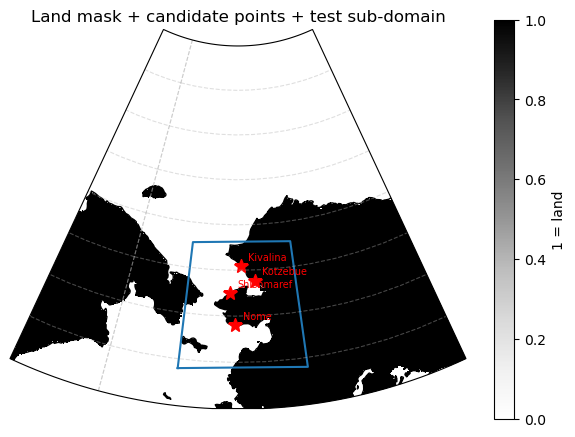

In [16]:
geo0 = tile_geometry[0] if not use_patches else None

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection=proj)
cf = ax.pcolormesh(hlon, hlat, land_mask[0, 0], cmap="Greys", vmin=0, vmax=1,
                    shading="auto", transform=ccrs.PlateCarree())
if geo0 is not None:
    ax.plot(
        [geo0["target_lon"].min(), geo0["target_lon"].max(), geo0["target_lon"].max(), geo0["target_lon"].min(), geo0["target_lon"].min()],
        [geo0["target_lat"].min(), geo0["target_lat"].min(), geo0["target_lat"].max(), geo0["target_lat"].max(), geo0["target_lat"].min()],
        color="tab:blue", linewidth=1.5, transform=ccrs.PlateCarree(), label="test sub-domain",
    )
style_polar_ax(ax, proj, boundary_path, bbox)
ax.set_title("Land mask + candidate points" + (" + test sub-domain" if geo0 is not None else ""))
fig.colorbar(cf, ax=ax, shrink=0.7, label="1 = land")
plt.tight_layout()
plt.show()


## 1. Domain-mean SIT time series

Recomputed directly from the saved fields (ocean-weighted mean over the
test sub-domain), so you can freely change the date range, resampling, or
styling below. Only meaningful for `use_patches=False` runs.

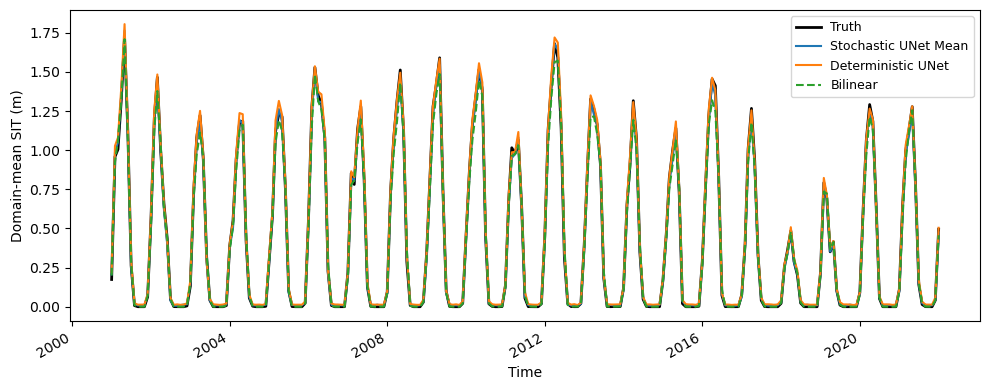

In [17]:
if use_patches:
    print("use_patches=True: no single coherent domain to average over -- skipping.")
else:
    ocean_weight = (1.0 - mask_test[0, 0]).clip(0, 1)  # (H, W); same land mask for every no-patch sample
    weight_sum = ocean_weight.sum()

    def domain_mean(field_phys):
        return (field_phys[:, 0] * ocean_weight[None, :, :]).sum(axis=(1, 2)) / weight_sum

    ts_df = sample_times_df.copy()
    ts_df["truth"] = domain_mean(Y_test_phys)
    ts_df["stochastic_unet_mean"] = domain_mean(Y_pred_phys)
    ts_df["deterministic_unet"] = domain_mean(Y_pred_det_phys)
    ts_df["bilinear"] = domain_mean(Y_base_phys)
    ts_df = ts_df.sort_values("time").reset_index(drop=True)

    # ---- customize here ----
    DATE_RANGE = None          # e.g. ("2006-01-01", "2010-12-31"), or None for all
    RESAMPLE = None            # e.g. "YS" (annual mean), "MS" (monthly), or None for raw samples
    METHODS = {                # label -> (column, color, linestyle)
        "Truth": ("truth", "black", "-"),
        "Stochastic UNet Mean": ("stochastic_unet_mean", "tab:blue", "-"),
        "Deterministic UNet": ("deterministic_unet", "tab:orange", "-"),
        "Bilinear": ("bilinear", "tab:green", "--"),
    }
    # -------------------------

    plot_df = ts_df
    if DATE_RANGE is not None:
        plot_df = plot_df[(plot_df["time"] >= DATE_RANGE[0]) & (plot_df["time"] <= DATE_RANGE[1])]
    if RESAMPLE is not None:
        plot_df = plot_df.set_index("time").resample(RESAMPLE).mean(numeric_only=True).reset_index()

    fig, ax = plt.subplots(figsize=(10, 4))
    for label, (col, color, ls) in METHODS.items():
        ax.plot(plot_df["time"], plot_df[col], label=label, color=color, linestyle=ls,
                 linewidth=2 if col == "truth" else 1.5)
    ax.set_ylabel("Domain-mean SIT (m)")
    ax.set_xlabel("Time")
    ax.legend(fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    ts_df.head()


## 2. Candidate-point time series (Kivalina, Shishmaref, Kotzebue, Nome)

Nearest-grid-cell time series at each named point, recomputed directly from the saved fields
(same "recompute, don't trust the precomputed file" approach as section 1). The nearest-cell
search excludes both land cells *and* cells where "truth" is ~constant over time: bilinear
regridding onto the high-res target grid bleeds the land-side fill value (0) into cells right at
the coast, which pass the land mask (regridded ocean fraction > 0.5) but are still numerically
flat -- a land-only exclusion doesn't catch these, which is why some "truth" lines were flat even
though the nearest cell wasn't technically land. Doing the lookup here (rather than only reading
`candidate_point_timeseries.csv`, which used the old land-only lookup) fixes this for runs that
already finished without needing to retrain.

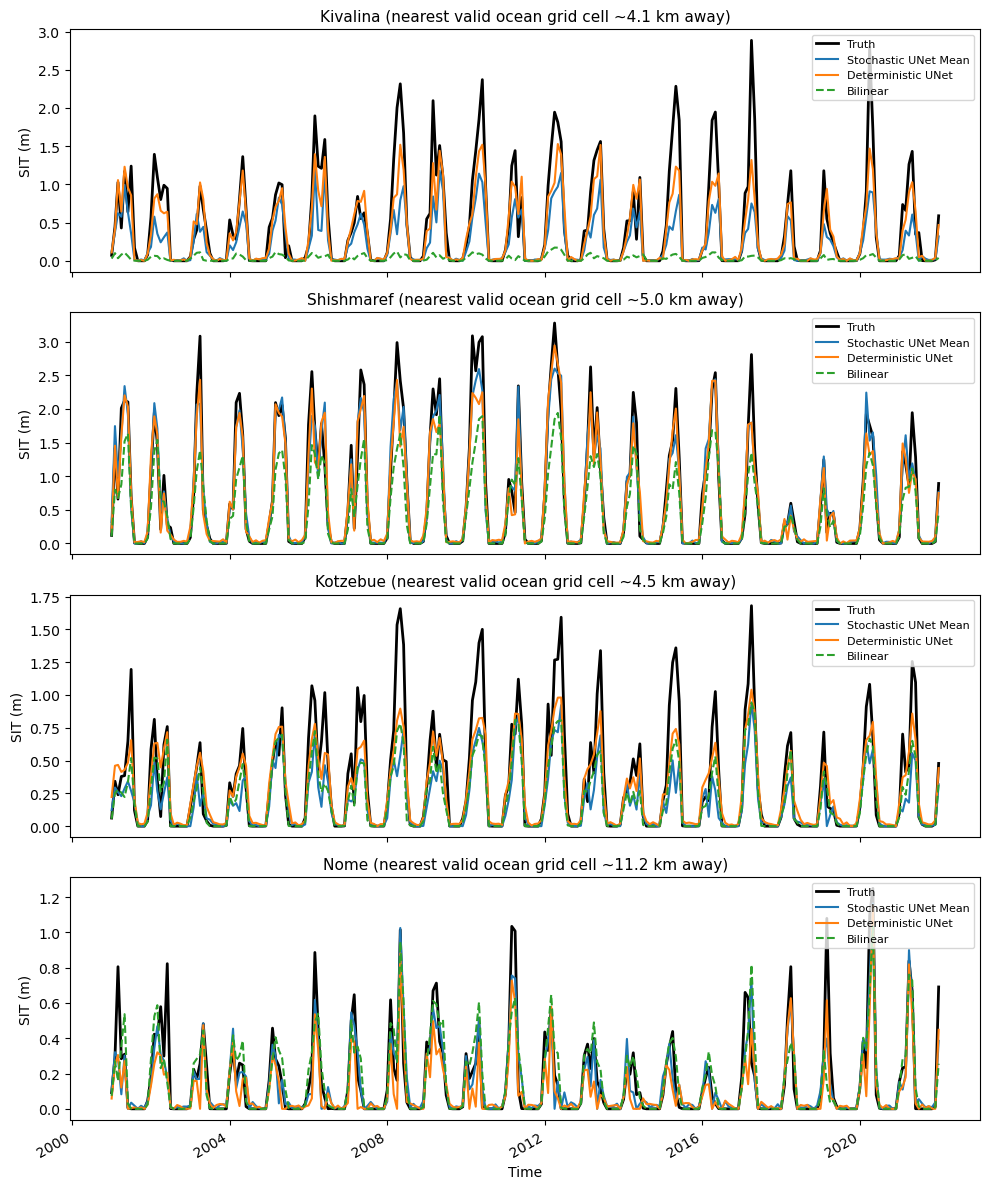

In [18]:
if use_patches:
    print("use_patches=True: no single coherent target grid to search across all test tiles -- skipping.")
else:
    def nearest_valid_index(lat_grid, lon_grid, exclude_hw, point_lat, point_lon_360):
        """Nearest (iy, ix) grid cell not flagged in exclude_hw (True/nonzero = excluded).
        point_lon_360 and lon_grid must both be in [0, 360) convention."""
        lat_grid = np.asarray(lat_grid)
        lon_grid = np.asarray(lon_grid) % 360
        dlat_deg = lat_grid[:, None] - point_lat
        dlon_deg = (lon_grid[None, :] - point_lon_360 + 180) % 360 - 180
        dlon_deg = dlon_deg * np.cos(np.deg2rad(point_lat))
        dist2 = dlat_deg ** 2 + dlon_deg ** 2
        valid = ~np.asarray(exclude_hw).astype(bool)
        dist2 = np.where(valid, dist2, np.inf)
        iy, ix = np.unravel_index(np.argmin(dist2), dist2.shape)
        return int(iy), int(ix), float(np.sqrt(dist2[iy, ix])) * 111.0

    geo = tile_geometry[0]
    target_lat, target_lon = geo["target_lat"], geo["target_lon"]
    land_mask_hw = mask_test[0, 0]   # (H, W); same crop for every no-patch sample

    # Exclude land AND cells where "truth" is ~constant over time. Bilinear
    # regridding onto the high-res target grid bleeds the land-side fill
    # value (0) into cells right at the coast -- these pass the land mask
    # (regridded ocean fraction > 0.5) but are still numerically flat, so a
    # land-only exclusion doesn't catch them (this is exactly what produced
    # the flat Kivalina/Kotzebue "truth" lines before this fix).
    FLAT_STD_TOL = 1e-6   # meters of SIT
    flat_hw = Y_test_phys[:, 0].std(axis=0) < FLAT_STD_TOL
    exclude_hw = (land_mask_hw > 0.5) | flat_hw

    fields_phys = {
        "truth": Y_test_phys, "bilinear": Y_base_phys,
        "deterministic_unet": Y_pred_det_phys, "stochastic_unet_mean": Y_pred_phys,
    }
    time_index = sample_times_df["time"]

    locations = {}
    rows = []
    for point_name, pt in candidate_points.items():
        iy, ix, dist_km = nearest_valid_index(target_lat, target_lon, exclude_hw, pt["lat"], pt["lon"])
        locations[point_name] = (iy, ix, dist_km)
        for method_name, field in fields_phys.items():
            values = field[:, 0, iy, ix]
            for t, v in zip(time_index, values):
                rows.append({"point": point_name, "method": method_name, "time": t, "value": float(v),
                             "grid_iy": iy, "grid_ix": ix, "dist_km": dist_km})
    point_df = pd.DataFrame(rows).sort_values(["point", "method", "time"]).reset_index(drop=True)

    # ---- customize here ----
    POINTS_TO_PLOT = list(candidate_points.keys())   # subset if you only want e.g. ["Kivalina"]
    METHOD_STYLE = {
        "truth": ("Truth", "black", "-", 2),
        "stochastic_unet_mean": ("Stochastic UNet Mean", "tab:blue", "-", 1.5),
        "deterministic_unet": ("Deterministic UNet", "tab:orange", "-", 1.5),
        "bilinear": ("Bilinear", "tab:green", "--", 1.5),
    }
    DATE_RANGE = None   # e.g. ("2006-01-01", "2010-12-31")
    # -------------------------

    fig, axs = plt.subplots(len(POINTS_TO_PLOT), 1, figsize=(10, 3 * len(POINTS_TO_PLOT)), sharex=True)
    if len(POINTS_TO_PLOT) == 1:
        axs = [axs]

    for ax, point_name in zip(axs, POINTS_TO_PLOT):
        sub = point_df[point_df["point"] == point_name]
        if DATE_RANGE is not None:
            sub = sub[(sub["time"] >= DATE_RANGE[0]) & (sub["time"] <= DATE_RANGE[1])]
        iy, ix, dist_km = locations[point_name]

        for method, (label, color, ls, lw) in METHOD_STYLE.items():
            m = sub[sub["method"] == method].sort_values("time")
            ax.plot(m["time"], m["value"], label=label, color=color, linestyle=ls, linewidth=lw)

        ax.set_title(f"{point_name} (nearest valid ocean grid cell ~{dist_km:.1f} km away)", fontsize=11)
        ax.set_ylabel("SIT (m)")
        ax.legend(fontsize=8, loc="upper right")

    axs[-1].set_xlabel("Time")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


## 3. Ensemble figure (customizable)

Low-res input, bilinear, deterministic, one ensemble member, ensemble
mean, and truth, for a chosen set of test samples.

In [30]:
# ---- customize here ----
N_SAMPLES = min(3, Y_test_phys.shape[0])
MIN_ICE_THICKNESS = 0.5  # m; pixels below this don't count as "ice present"
MIN_ICE_FRAC = 0.25       # require at least this fraction of the target tile to have ice

ice_frac = (Y_test_phys[:, 0] > MIN_ICE_THICKNESS).mean(axis=(1, 2))
valid_idxs = np.where(ice_frac > MIN_ICE_FRAC)[0]

if len(valid_idxs) < N_SAMPLES:
    raise ValueError(f"Only {len(valid_idxs)} samples meet the ice criteria, need {N_SAMPLES}")

SAMPLE_IDXS = np.random.default_rng().choice(valid_idxs, N_SAMPLES, replace=False)
MEMBER_IDX = min(4, preds_all_phys.shape[1] - 1)   # which ensemble member to show in the "One Member" column
VMIN, VMAX = 0, 3
CMAP = "Blues"
SHOW_POINTS = True   # overlay candidate-point markers

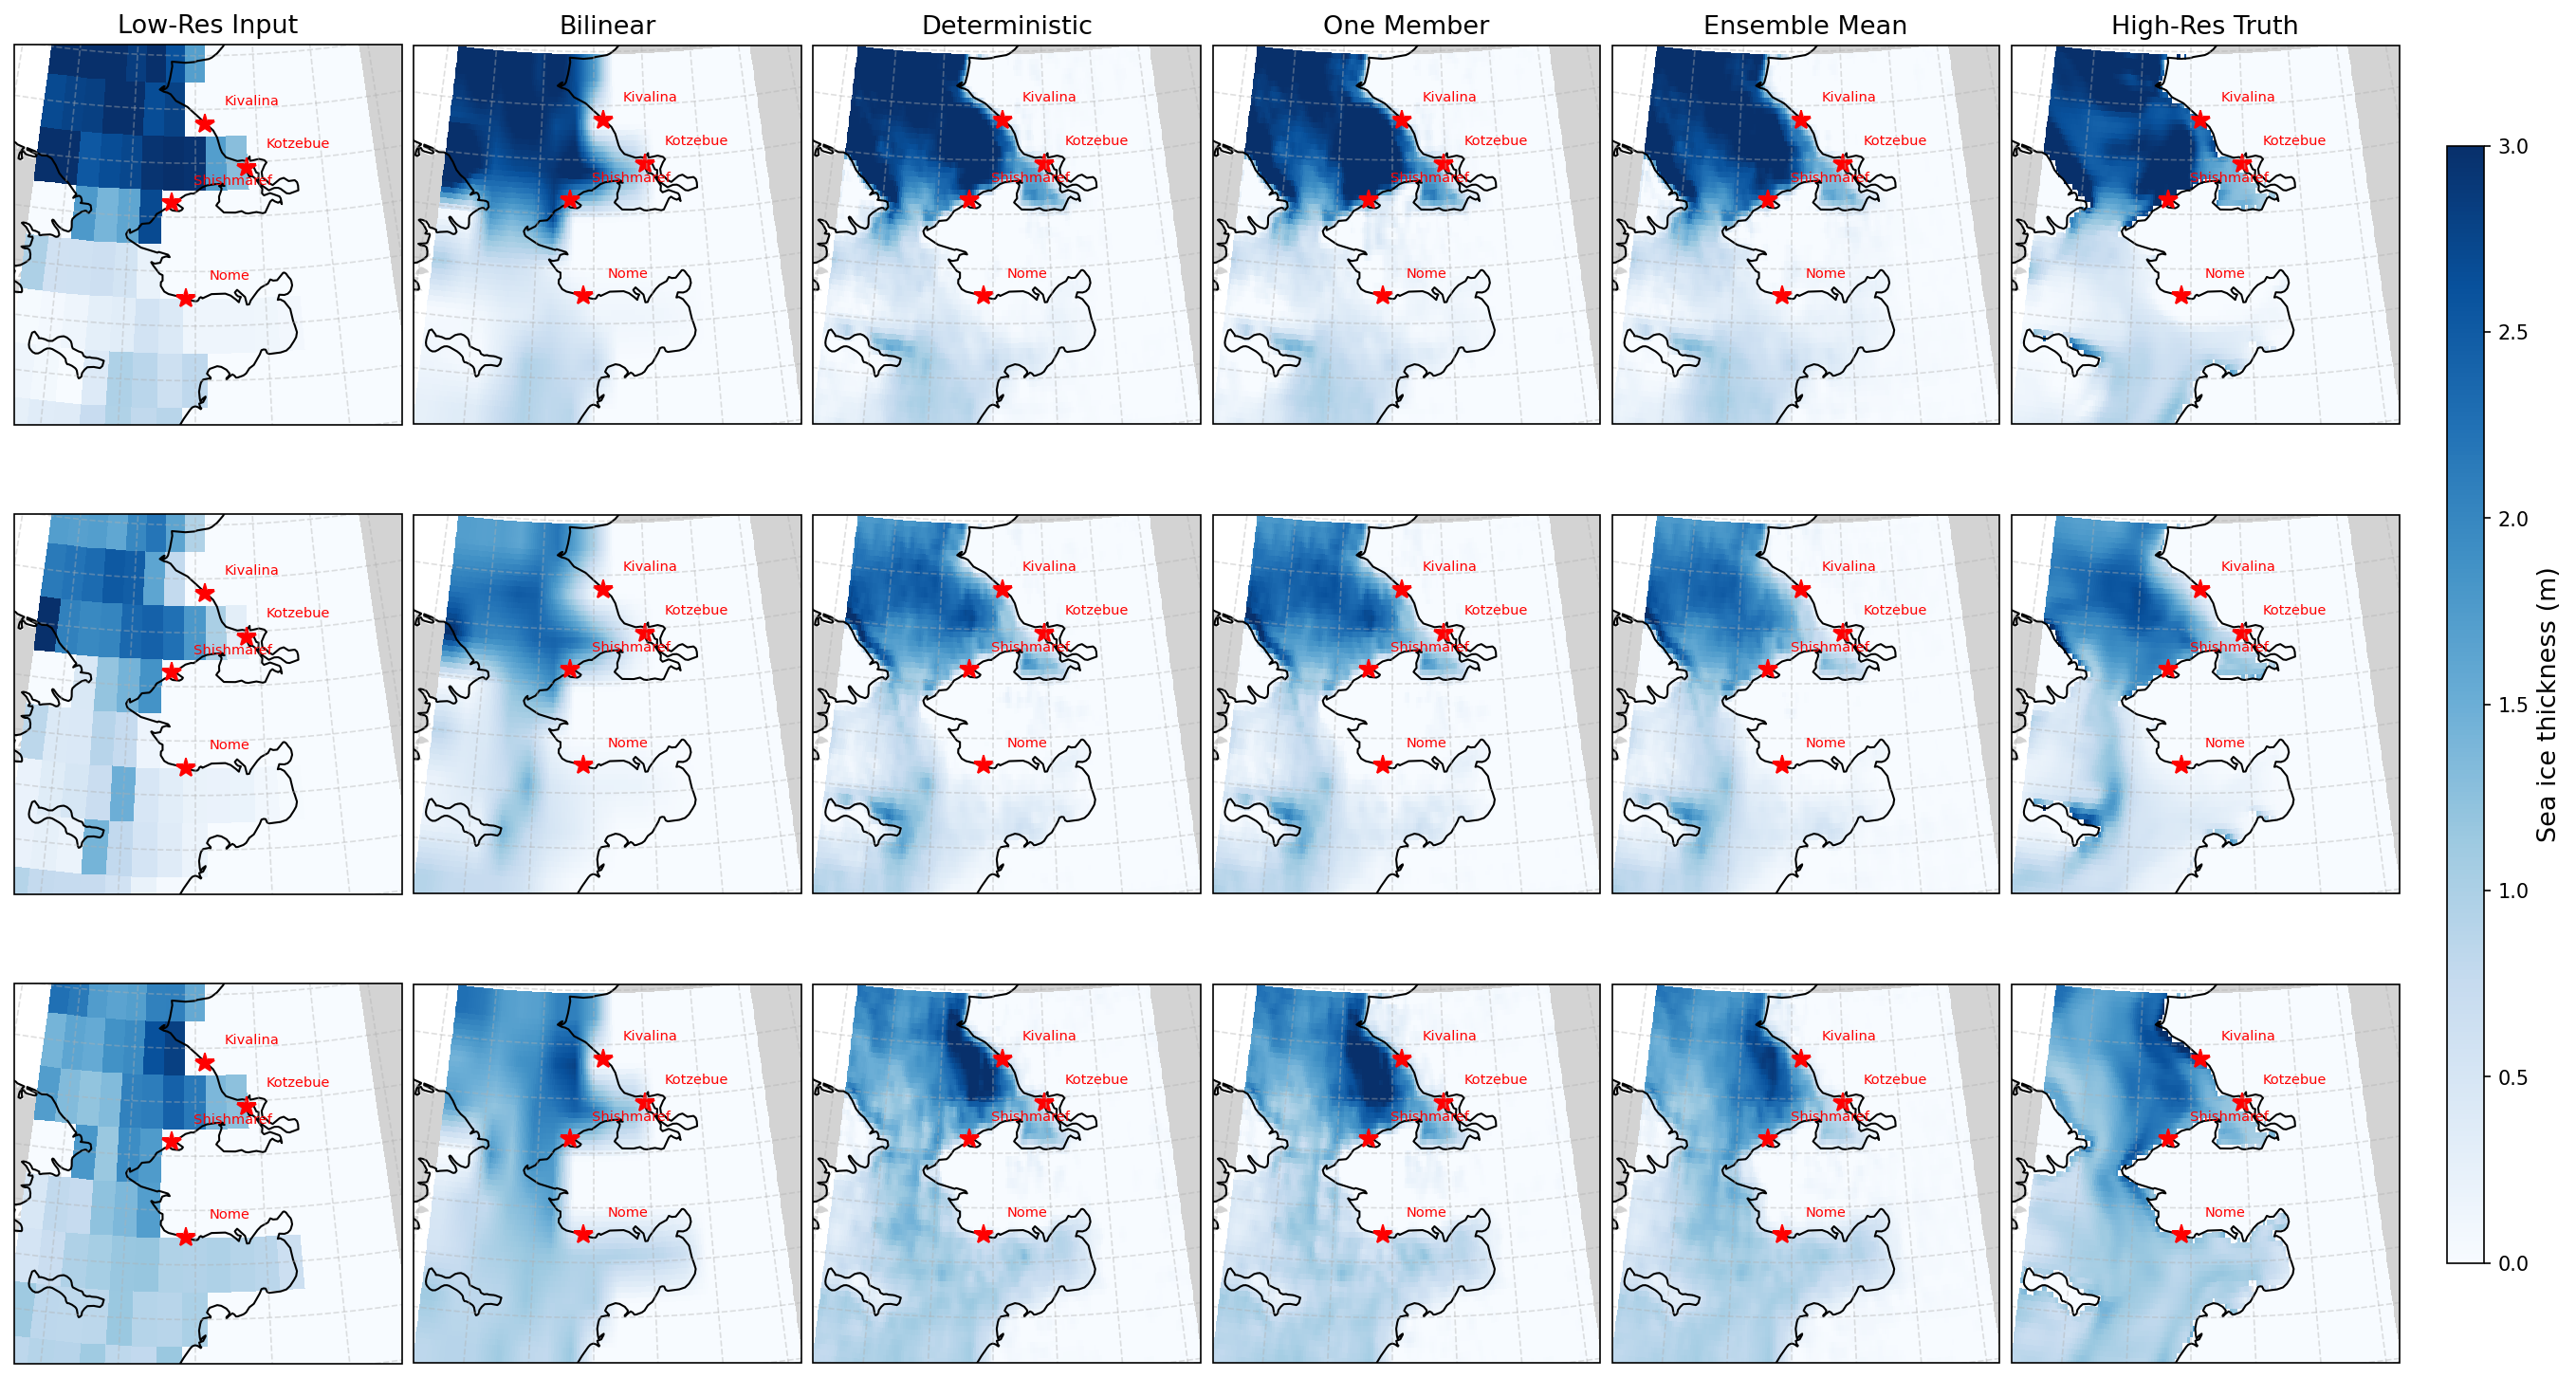

In [31]:
panel_titles = ["Low-Res Input", "Bilinear", "Deterministic", "One Member", "Ensemble Mean", "High-Res Truth"]

fig, axs = plt.subplots(
    len(SAMPLE_IDXS), 6, figsize=(18, 3.3 * len(SAMPLE_IDXS)), constrained_layout=True, dpi=150,
    subplot_kw={"projection": proj},
)
if len(SAMPLE_IDXS) == 1:
    axs = axs[None, :]

for row, idx in enumerate(SAMPLE_IDXS):
    geo = tile_geometry[int(test_tile_ids[idx])]
    ctx_lon, ctx_lat = geo["context_lon"], geo["context_lat"]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]

    fields_row = [
        X_test_sit_phys[idx, 0], Y_base_phys[idx, 0], Y_pred_det_phys[idx, 0],
        preds_all_phys[idx, MEMBER_IDX, 0], Y_pred_phys[idx, 0], Y_test_phys[idx, 0],
    ]
    lons = [ctx_lon, tgt_lon, tgt_lon, tgt_lon, tgt_lon, tgt_lon]
    lats = [ctx_lat, tgt_lat, tgt_lat, tgt_lat, tgt_lat, tgt_lat]

    for col, (field, lon_, lat_) in enumerate(zip(fields_row, lons, lats)):
        ax = axs[row, col]
        im = ax.pcolormesh(lon_, lat_, field, transform=ccrs.PlateCarree(), cmap=CMAP,
                            vmin=VMIN, vmax=VMAX, shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, lon_, lat_, points=candidate_points if SHOW_POINTS else {})
        if row == 0:
            ax.set_title(panel_titles[col], fontsize=13)

    axs[row, 0].set_ylabel(f"Sample {row + 1}", fontsize=13)

cbar = fig.colorbar(im, ax=axs, aspect=30, shrink=0.8, pad=0.02)
cbar.set_label("Sea ice thickness (m)", fontsize=13)
plt.show()


## 4. Error figure (customizable)

Absolute error vs. truth for bilinear, deterministic, and ensemble mean,
for the same (or a different) set of test samples.

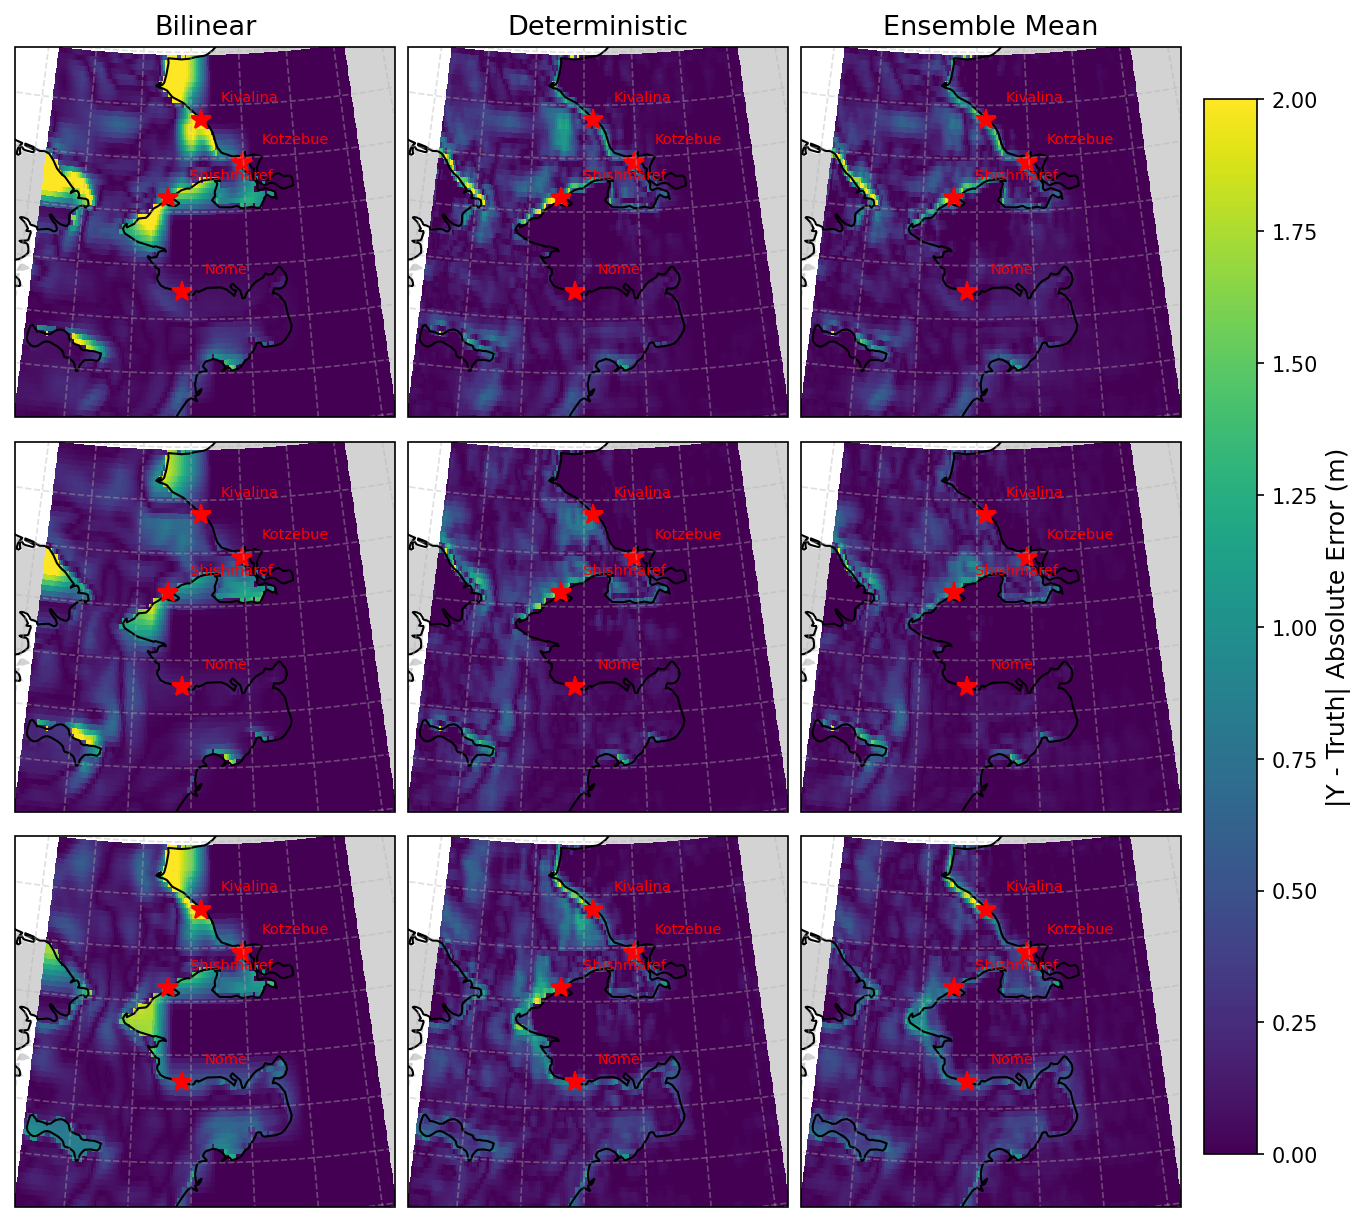

In [32]:
# ---- customize here ----
ERR_SAMPLE_IDXS = SAMPLE_IDXS   # reuse the same samples as above, or pick your own
ERR_VMIN, ERR_VMAX = 0, 2
ERR_CMAP = "viridis"
SHOW_POINTS = True
# -------------------------

panel_titles_err = ["Bilinear", "Deterministic", "Ensemble Mean"]

fig, axs = plt.subplots(
    len(ERR_SAMPLE_IDXS), 3, figsize=(9, 2.7 * len(ERR_SAMPLE_IDXS)), constrained_layout=True, dpi=150,
    subplot_kw={"projection": proj},
)
if len(ERR_SAMPLE_IDXS) == 1:
    axs = axs[None, :]

for row, idx in enumerate(ERR_SAMPLE_IDXS):
    geo = tile_geometry[int(test_tile_ids[idx])]
    tgt_lon, tgt_lat = geo["target_lon"], geo["target_lat"]

    truth = Y_test_phys[idx, 0]
    bilinear_ae = np.abs(Y_base_phys[idx, 0] - truth)
    det_ae = np.abs(Y_pred_det_phys[idx, 0] - truth)
    ens_ae = np.abs(Y_pred_phys[idx, 0] - truth)

    for col, field in enumerate([bilinear_ae, det_ae, ens_ae]):
        ax = axs[row, col]
        im = ax.pcolormesh(tgt_lon, tgt_lat, field, transform=ccrs.PlateCarree(), cmap=ERR_CMAP,
                            vmin=ERR_VMIN, vmax=ERR_VMAX, shading="auto")
        style_polar_ax(ax, proj, boundary_path, bbox, tgt_lon, tgt_lat, points=candidate_points if SHOW_POINTS else {})
        if row == 0:
            ax.set_title(panel_titles_err[col], fontsize=13)

    axs[row, 0].set_ylabel(f"Sample {row + 1}", fontsize=13)

cbar = fig.colorbar(im, ax=axs, aspect=20, shrink=0.9, pad=0.02)
cbar.set_label("|Y - Truth| Absolute Error (m)", fontsize=12)
plt.show()
